In [1]:
import sys, os
import re
import gc
import glob
import pandas as pd
import ast
import itertools
import numpy as np
from pathlib import Path

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
from tqdm.notebook import tqdm

tqdm.pandas()

In [4]:
import warnings
warnings.filterwarnings("ignore")

### Loading package

In [5]:
import sys
from pathlib import Path

here_path = Path().resolve()
repo_path = here_path.parents[1]
sys.path.append(str(repo_path))

In [7]:
from py.config import Config

cfg = Config()

np.random.seed(cfg.RANDOM_STATE)
cfg.DATA_PATH, cfg.MODEL_PATH

('/media/felipe/DATA21/datasets/', '/media/felipe/DATA21/models/')

### Loading data

In [8]:
DATA_PATH=f"{cfg.DATA_PATH}postcog/"
CSV_PATH = f"{DATA_PATH}/csv/"
THREADS_PROCESSED = f"{CSV_PATH}/topics/{cfg.TOPIC_SEARCH}/"

In [9]:
data_df = pd.read_csv(f"{THREADS_PROCESSED}/Websites_Languages.csv", sep="\t", low_memory=False, encoding='utf-8')
data_df.rename(columns={"crime_type": "crimetype", "intent": "intention"}, inplace=True)
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6496 entries, 0 to 6495
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sitename              6496 non-null   str    
 1   board_title           6496 non-null   str    
 2   thread_title          6496 non-null   str    
 3   thread_id             6496 non-null   int64  
 4   content               6496 non-null   str    
 5   crimetype             6496 non-null   str    
 6   cve_codes_list        6496 non-null   str    
 7   intention             2809 non-null   str    
 8   posttype              2814 non-null   str    
 9   cve_unique_list       6496 non-null   str    
 10  r_IMG                 6496 non-null   str    
 11  r_CITING              6496 non-null   str    
 12  r_IFRAME              6496 non-null   str    
 13  r_LINK                6496 non-null   str    
 14  r_CODE                6496 non-null   str    
 15  r_ATTACHMENT          6496 non-n

#### Processing texts

In [10]:
data_df["lang_detected"].value_counts()

lang_detected
english       3228
russian       1967
spanish       1223
not found       53
portuguese      21
deutsch          4
Name: count, dtype: int64

In [11]:
LANGUAGE_TO_EVAL=[lang for lang in data_df["lang_detected"].unique() if lang!="not found"]
# LANGUAGE_TO_EVAL=["english"]

In [12]:
filter_df = data_df[data_df["lang_detected"].isin(LANGUAGE_TO_EVAL)].copy()
#filter_df.dropna(subset=['intent', 'crime_type', 'posttype'], inplace=True)
filter_df.reset_index(inplace=True, drop=True)
filter_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6443 entries, 0 to 6442
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sitename              6443 non-null   str    
 1   board_title           6443 non-null   str    
 2   thread_title          6443 non-null   str    
 3   thread_id             6443 non-null   int64  
 4   content               6443 non-null   str    
 5   crimetype             6443 non-null   str    
 6   cve_codes_list        6443 non-null   str    
 7   intention             2776 non-null   str    
 8   posttype              2781 non-null   str    
 9   cve_unique_list       6443 non-null   str    
 10  r_IMG                 6443 non-null   str    
 11  r_CITING              6443 non-null   str    
 12  r_IFRAME              6443 non-null   str    
 13  r_LINK                6443 non-null   str    
 14  r_CODE                6443 non-null   str    
 15  r_ATTACHMENT          6443 non-n

### ChatGPT Labeling

#### Post type

In [13]:
print( "Nan", len(filter_df[ filter_df["posttype"].isna() ]) )
filter_df["posttype"].value_counts()

Nan 3662


posttype
infoRequest    986
comment        956
offerX         555
exchange        78
social          71
requestX        70
tutorial        65
Name: count, dtype: int64

In [14]:
filter_df["posttype"] = filter_df["posttype"].apply(lambda x: "other" if pd.isna(x) else x )
filter_df["posttype"].value_counts()

posttype
other          3662
infoRequest     986
comment         956
offerX          555
exchange         78
social           71
requestX         70
tutorial         65
Name: count, dtype: int64

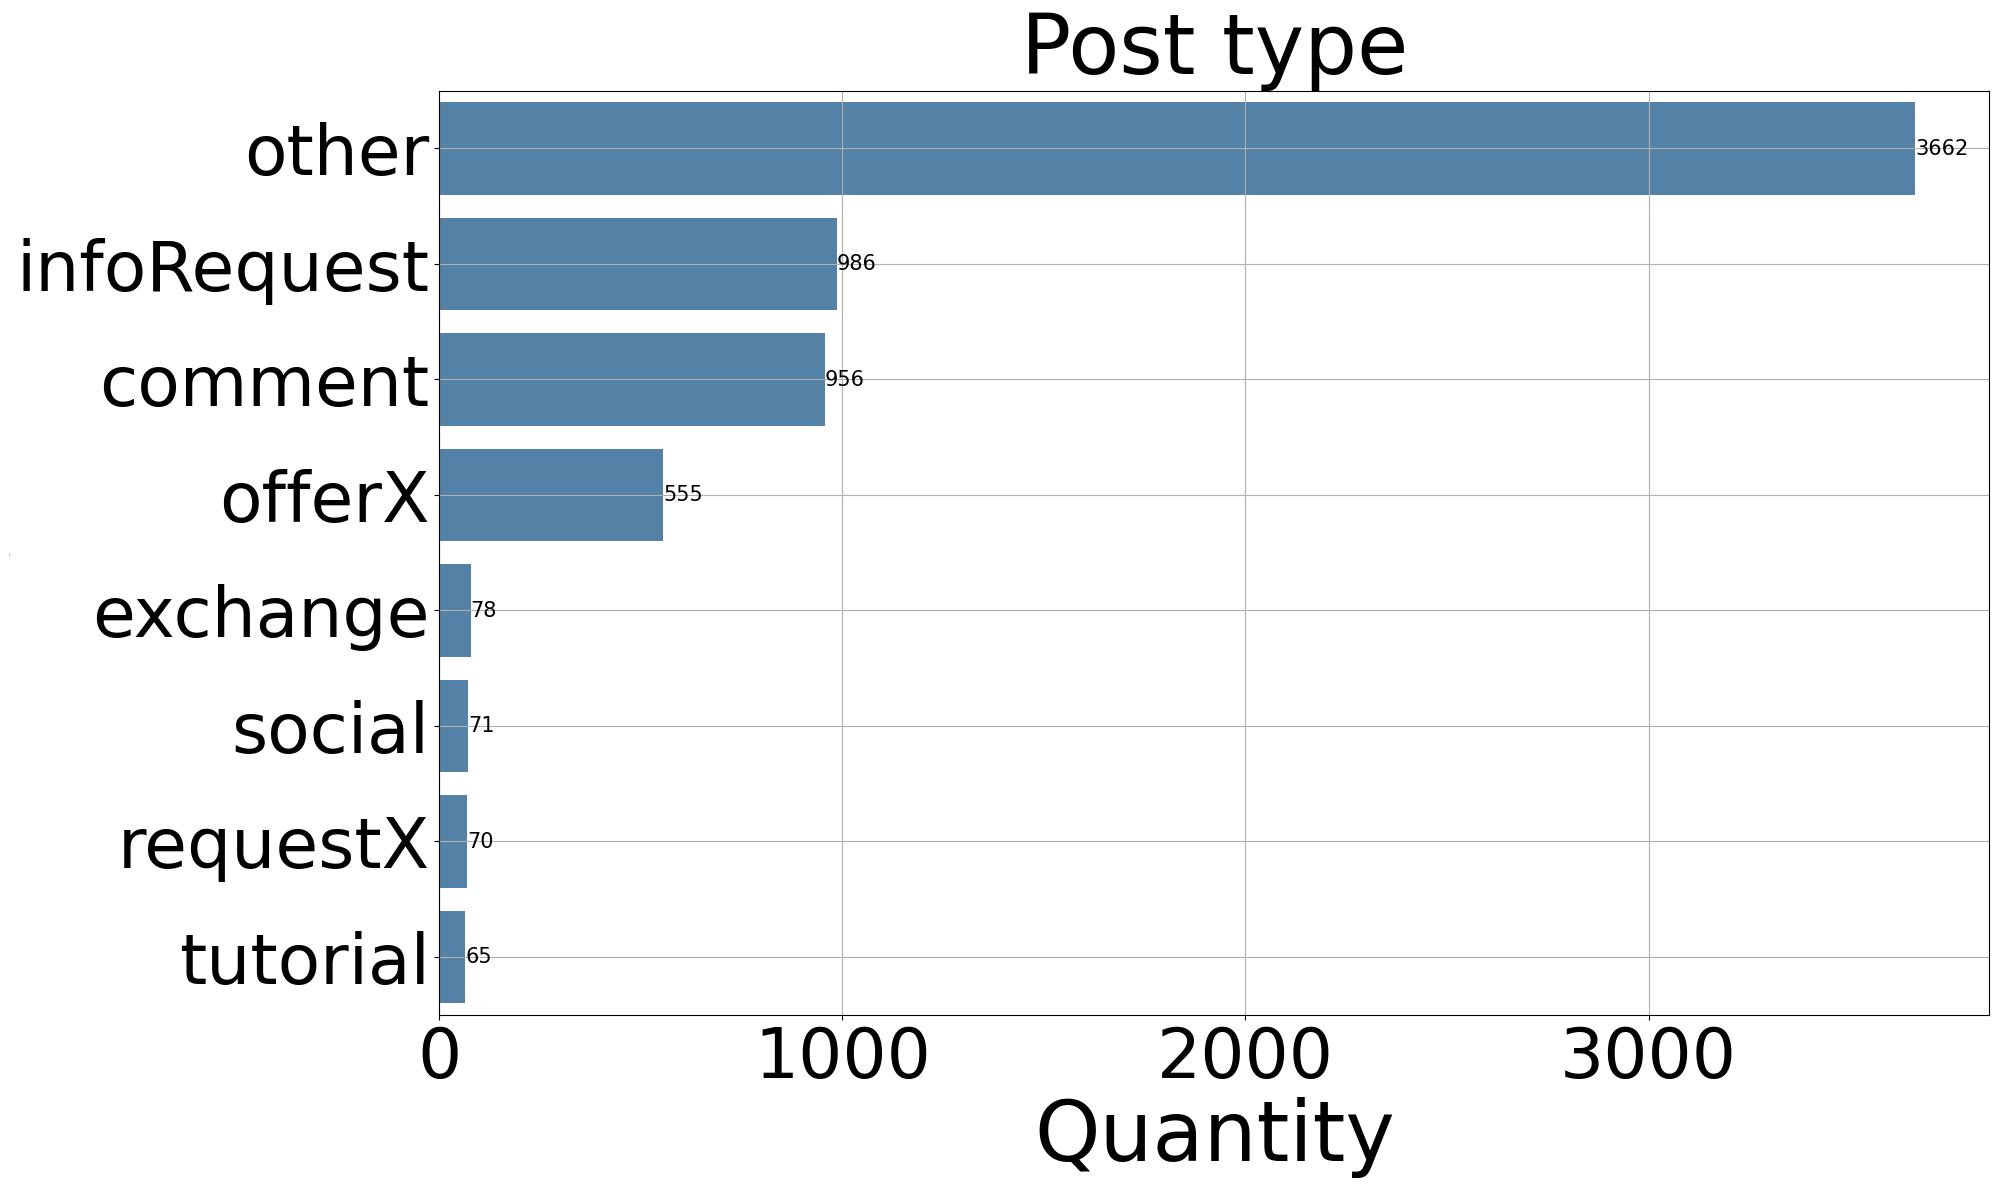

In [15]:
_, ax = plt.subplots(figsize=(20,12), nrows=1, ncols=1, sharex=False, sharey=False)

estado_df = pd.pivot_table(filter_df,
               index=["posttype"],
                values=["thread_id"],
                aggfunc={
                    "thread_id":len
                }).reset_index()

sns_fig = sns.barplot(
            data=estado_df,
            x=estado_df.columns[1],
            y=estado_df.columns[0],
            orient="h",
            ax=ax,
            color="steelblue",
            order=estado_df.sort_values(estado_df.columns[1], ascending=False)[estado_df.columns[0]]
           )

sns_fig.set_title(f"Post type", fontsize=60)
sns_fig.set_ylabel(f"Label", fontsize=0)
sns_fig.set_xlabel('Quantity', fontsize=60)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0, labelsize=50)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='y', labelsize=50)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f', fontsize=15,rotation=0)

# add a space on y for the annotations
#sns_fig.margins(x=0.1)
ax.grid(True)

In [16]:
def define_post(x):
    if pd.isna(x):
        return "other"
    else:
        if x in ["infoRequest", "requestX"]:
            return "requests"
        elif x in ["offerX", "exchange"]:
            return "offers/exchanges"
        elif x in ["tutorial", "comment", "social"]:
            return "communication/interaction"
        else: # Other
            return "other"

In [17]:
filter_df["chatgpt_posttype"] = filter_df["posttype"].apply(lambda x: define_post(x) )
filter_df["chatgpt_posttype"].value_counts()

chatgpt_posttype
other                        3662
communication/interaction    1092
requests                     1056
offers/exchanges              633
Name: count, dtype: int64

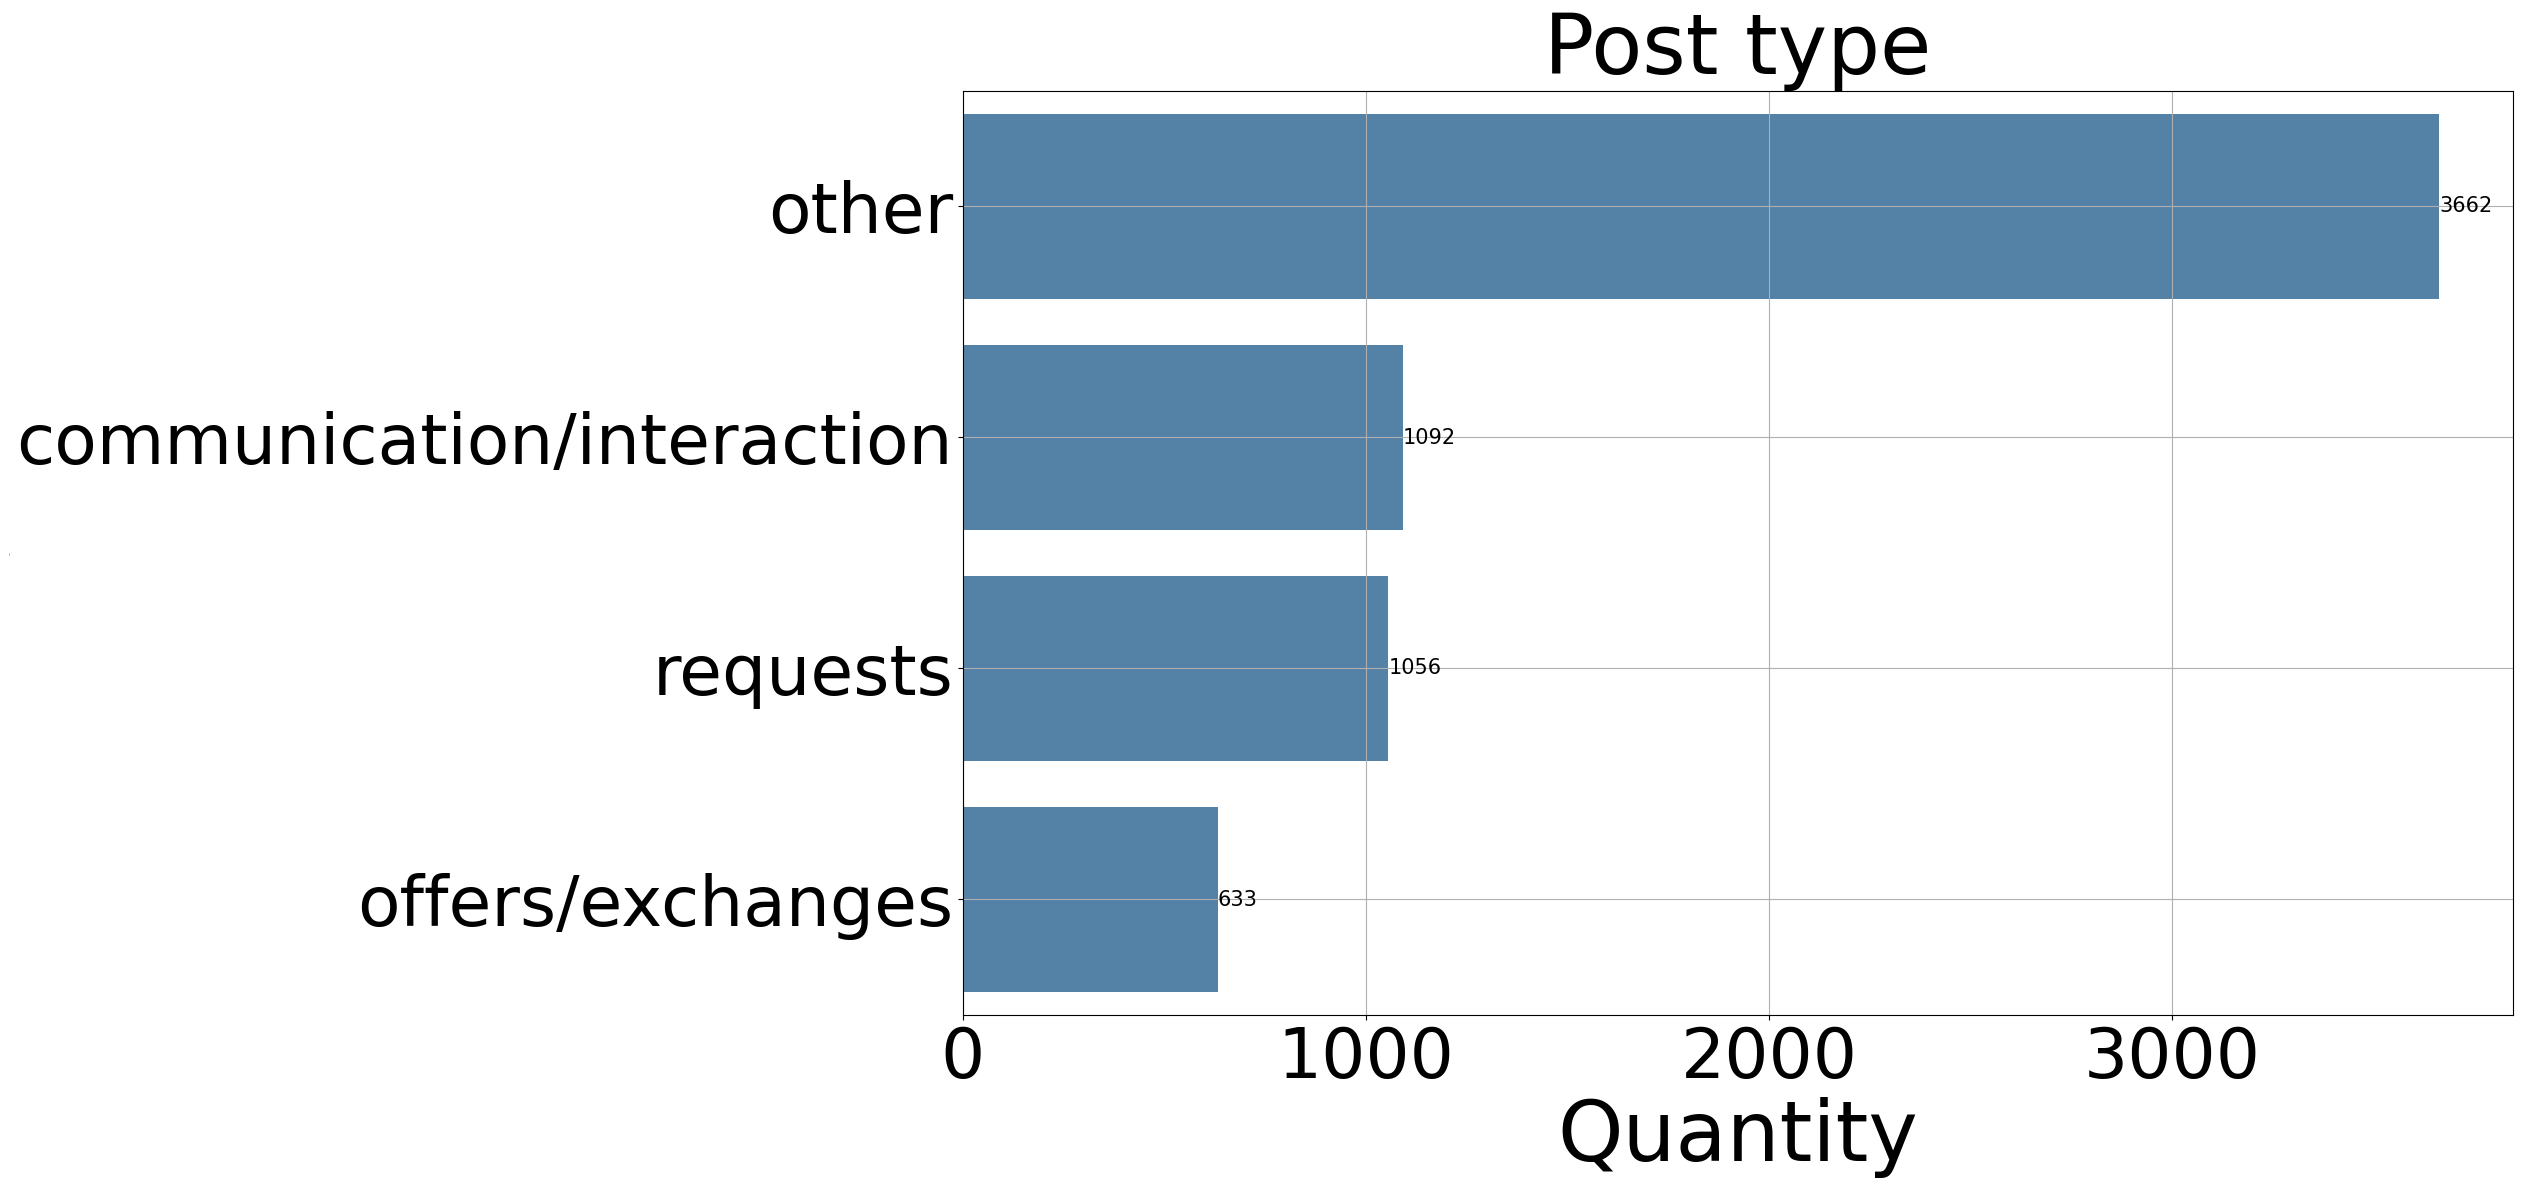

In [18]:
_, ax = plt.subplots(figsize=(20,12), nrows=1, ncols=1, sharex=False, sharey=False)

estado_df = pd.pivot_table(filter_df,
               index=["chatgpt_posttype"],
                values=["thread_id"],
                aggfunc={
                    "thread_id":len
                }).reset_index()

sns_fig = sns.barplot(
            data=estado_df,
            x=estado_df.columns[1],
            y=estado_df.columns[0],
            orient="h",
            ax=ax,
            color="steelblue",
            order=estado_df.sort_values(estado_df.columns[1], ascending=False)[estado_df.columns[0]]
           )

sns_fig.set_title(f"Post type", fontsize=60)
sns_fig.set_ylabel(f"Label", fontsize=0)
sns_fig.set_xlabel('Quantity', fontsize=60)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0, labelsize=50)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='y', labelsize=50)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f', fontsize=15,rotation=0)

# add a space on y for the annotations
#sns_fig.margins(x=0.1)
ax.grid(True)

### Intention

In [19]:
print( "Nan", len(filter_df[ filter_df["intention"].isna() ]) )
filter_df["intention"].value_counts()

Nan 3667


intention
neutral           2381
positive           146
gratitude           84
aggression          58
moderate            30
negative            30
vouch               25
privatemessage      22
Name: count, dtype: int64

In [20]:
filter_df["intention"] = filter_df["intention"].apply(lambda x: "other" if pd.isna(x) else x )
filter_df["intention"].value_counts()

intention
other             3667
neutral           2381
positive           146
gratitude           84
aggression          58
moderate            30
negative            30
vouch               25
privatemessage      22
Name: count, dtype: int64

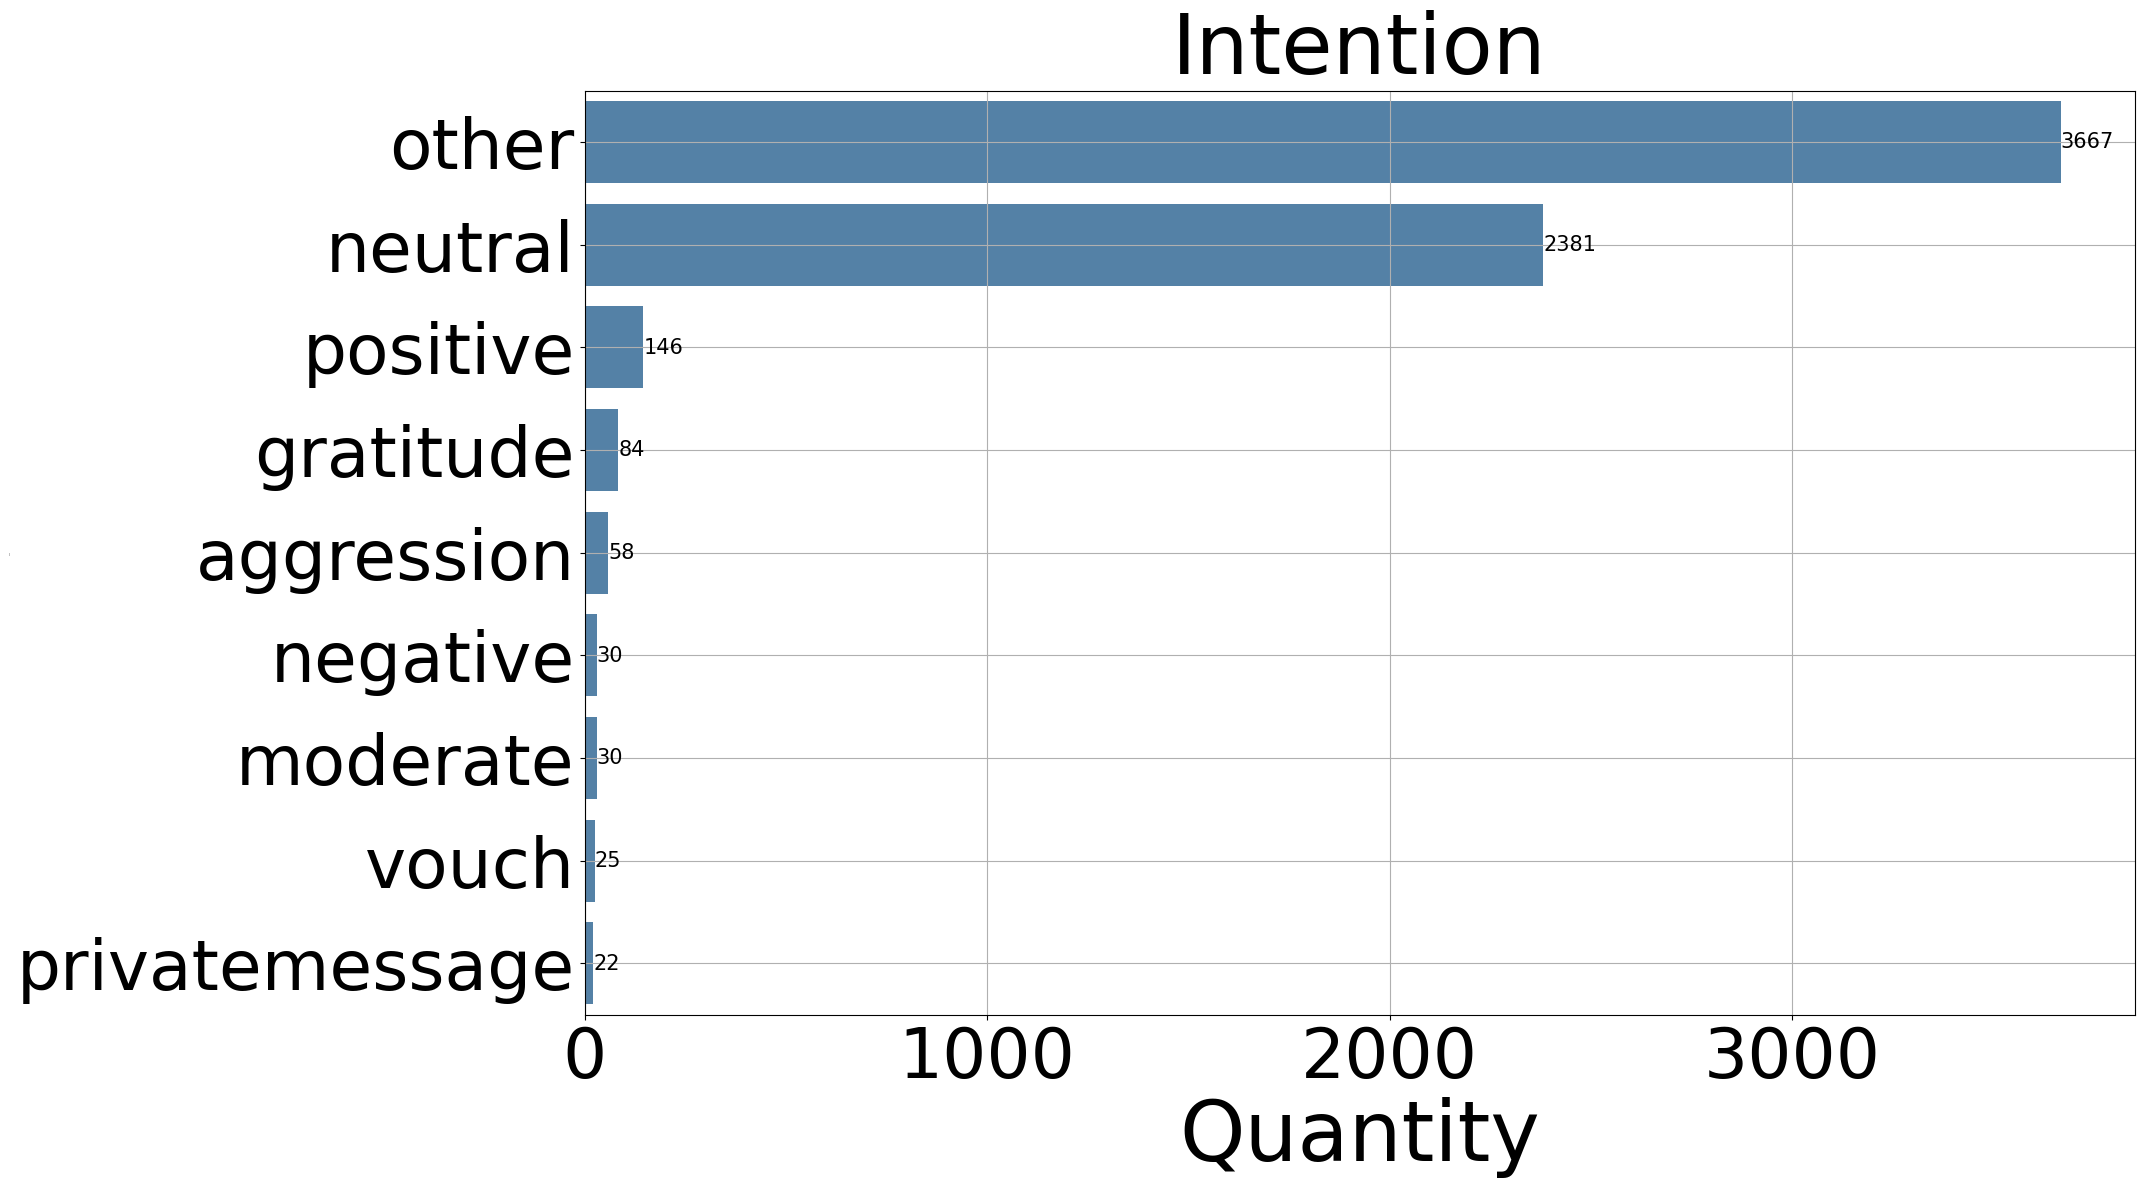

In [21]:
_, ax = plt.subplots(figsize=(20,12), nrows=1, ncols=1, sharex=False, sharey=False)

estado_df = pd.pivot_table(filter_df,
               index=["intention"],
                values=["thread_id"],
                aggfunc={
                    "thread_id":len
                }).reset_index()

sns_fig = sns.barplot(
            data=estado_df,
            x=estado_df.columns[1],
            y=estado_df.columns[0],
            orient="h",
            ax=ax,
            color="steelblue",
            order=estado_df.sort_values(estado_df.columns[1], ascending=False)[estado_df.columns[0]]
           )

sns_fig.set_title(f"Intention", fontsize=60)
sns_fig.set_ylabel(f"Label", fontsize=0)
sns_fig.set_xlabel('Quantity', fontsize=60)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0, labelsize=50)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='y', labelsize=50)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f', fontsize=15,rotation=0)

# add a space on y for the annotations
#sns_fig.margins(x=0.1)
ax.grid(True)

In [22]:
def define_intention(x):
    if pd.isna(x):
        return "other"
    else:
        if x in ["neutral", "positive", "negative"]:
            return "sentiment"
        elif x in ["gratitude", "vouch", "aggression", "privatemessage"]:
            return "expression"
        elif x =="moderate":
            return "intensity"
        else: # Other
            return "other"

In [23]:
filter_df["chatgpt_intention"] = filter_df["intention"].apply(lambda x: define_intention(x) )
filter_df["chatgpt_intention"].value_counts()

chatgpt_intention
other         3667
sentiment     2557
expression     189
intensity       30
Name: count, dtype: int64

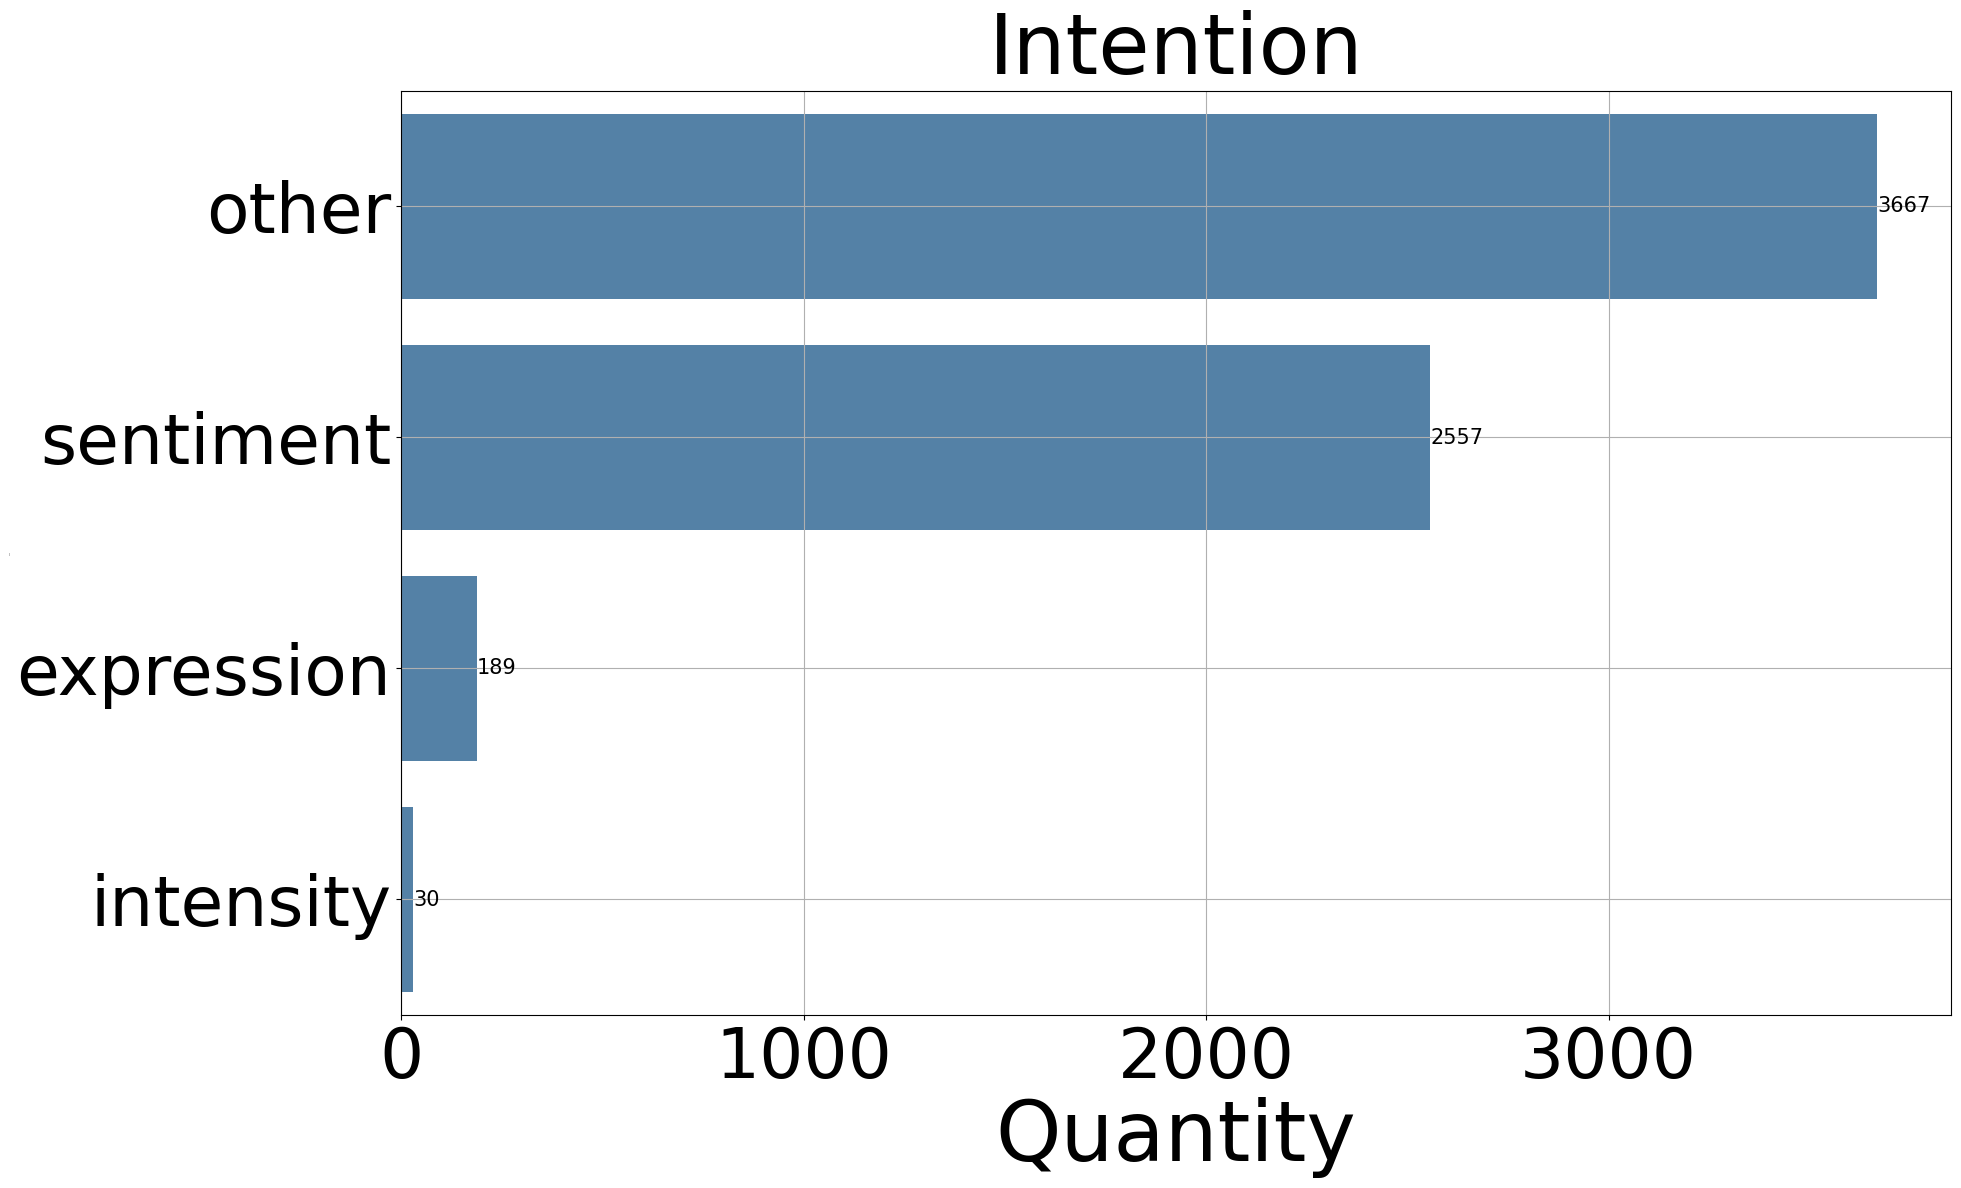

In [24]:
_, ax = plt.subplots(figsize=(20,12), nrows=1, ncols=1, sharex=False, sharey=False)

estado_df = pd.pivot_table(filter_df,
               index=["chatgpt_intention"],
                values=["thread_id"],
                aggfunc={
                    "thread_id":len
                }).reset_index()

sns_fig = sns.barplot(
            data=estado_df,
            x=estado_df.columns[1],
            y=estado_df.columns[0],
            orient="h",
            ax=ax,
            color="steelblue",
            order=estado_df.sort_values(estado_df.columns[1], ascending=False)[estado_df.columns[0]]
           )

sns_fig.set_title(f"Intention", fontsize=60)
sns_fig.set_ylabel(f"Label", fontsize=0)
sns_fig.set_xlabel('Quantity', fontsize=60)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0, labelsize=50)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='y', labelsize=50)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f', fontsize=15,rotation=0)

# add a space on y for the annotations
#sns_fig.margins(x=0.1)
ax.grid(True)

#### Crime type

In [25]:
BINARY_CRIME = False

In [26]:
crimetype_mapping = {
    "not criminal": "not criminal",
    "bots/malware": "bots/malware",
    'access to systems/sql injection': 'auth/sql injection',
    'trading credentials': 'credentials',
    'VPN/proxy/hosting': 'VPN/hosting',
    'DDoS/booting/stress testing': 'DDoS/booting',
    'spam related/sharing email addresses/marketing)': 'spam related',
    "currency exchange": "currencyXchange",
    'identity theft/identity fraud/credit card fraud': "identity fraud",
    "eWhoring": "eWhoring",
}

In [27]:
print( "Nan", len(filter_df[ filter_df["crimetype"].isna() ]) )
filter_df["crimetype"].value_counts()

Nan 0


crimetype
not criminal                                       5502
bots/malware                                        466
access to systems/sql injection                     289
trading credentials                                  81
VPN/proxy/hosting                                    65
DDoS/booting/stress testing                          28
spam related/sharing email addresses/marketing)       6
currency exchange                                     4
identity theft/identity fraud/credit card fraud       1
eWhoring                                              1
Name: count, dtype: int64

In [28]:
filter_df["crimetype"] = filter_df["crimetype"].apply(lambda x: "other" if pd.isna(x) else crimetype_mapping[x] )
filter_df["crimetype"].value_counts()

crimetype
not criminal          5502
bots/malware           466
auth/sql injection     289
credentials             81
VPN/hosting             65
DDoS/booting            28
spam related             6
currencyXchange          4
identity fraud           1
eWhoring                 1
Name: count, dtype: int64

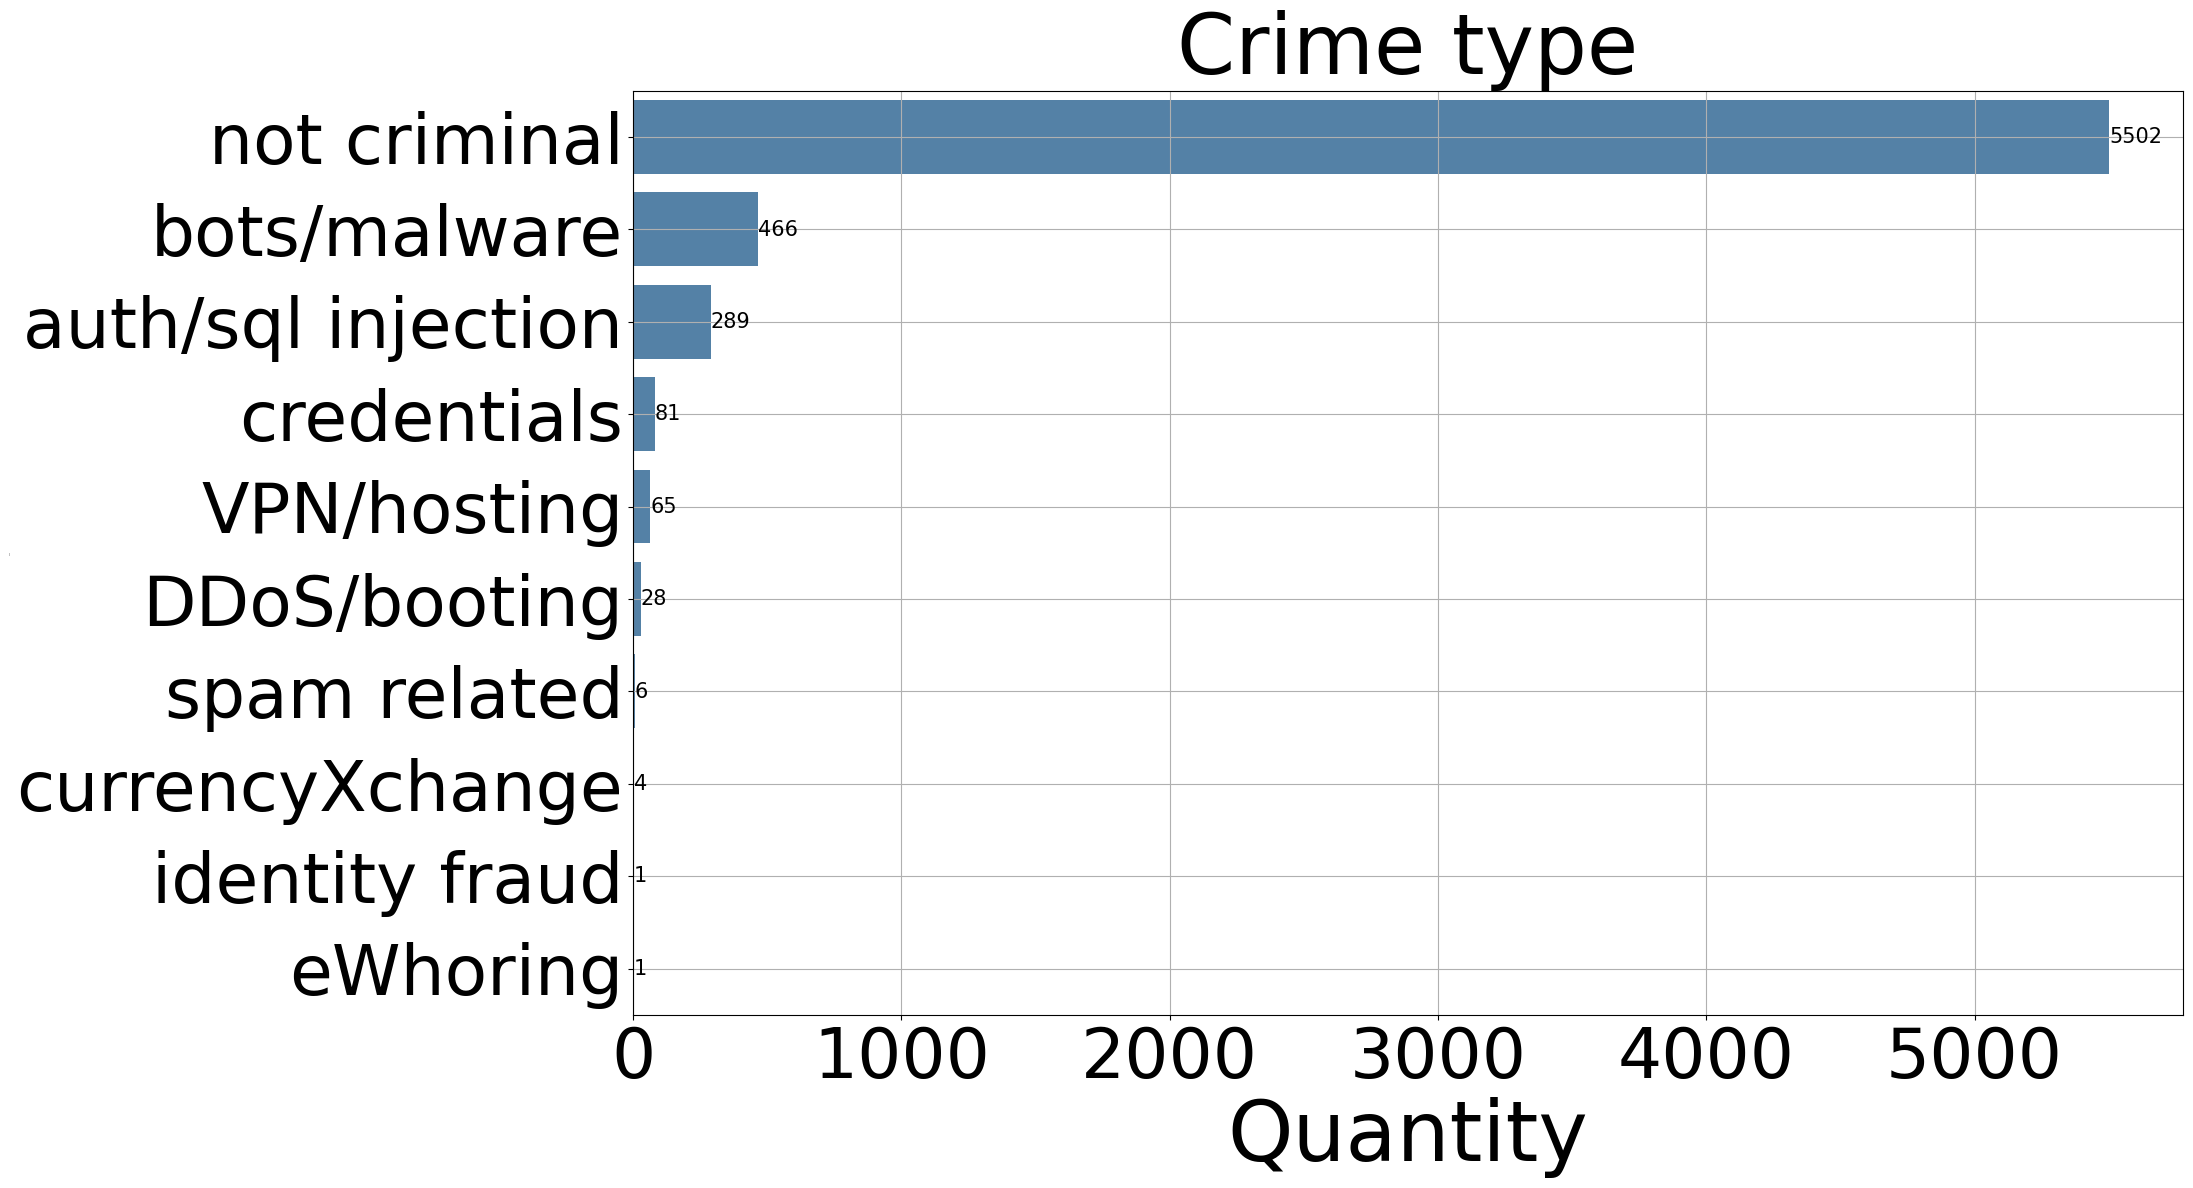

In [29]:
_, ax = plt.subplots(figsize=(20,12), nrows=1, ncols=1, sharex=False, sharey=False)

estado_df = pd.pivot_table(filter_df,
               index=["crimetype"],
                values=["thread_id"],
                aggfunc={
                    "thread_id":len
                }).reset_index()

sns_fig = sns.barplot(
            data=estado_df,
            x=estado_df.columns[1],
            y=estado_df.columns[0],
            orient="h",
            ax=ax,
            color="steelblue",
            order=estado_df.sort_values(estado_df.columns[1], ascending=False)[estado_df.columns[0]]
           )

sns_fig.set_title(f"Crime type", fontsize=60)
sns_fig.set_ylabel(f"Label", fontsize=0)
sns_fig.set_xlabel('Quantity', fontsize=60)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0, labelsize=50)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='y', labelsize=50)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f', fontsize=15,rotation=0)

# add a space on y for the annotations
#sns_fig.margins(x=0.1)
ax.grid(True)

In [30]:
def add_labels(x, mapping):
    return x + [mapping[i] for i in x]

ciber_support = add_labels(["VPN/proxy/hosting", "currency exchange"], crimetype_mapping)
ciber_activity = add_labels(["bots/malware", "access to systems/sql injection", "trading credentials", "DDoS/booting/stress testing", "spam related/sharing email addresses/marketing)", "eWhoring", "identity theft/identity fraud/credit card fraud"], crimetype_mapping)

def define_crime(x):
    if pd.isna(x):
        return np.nan
    else:
        if x=="not criminal":
            return x
        elif x in ciber_support:
            return "cybercrime support services"
        elif x in ciber_activity:
            return "cybercrime activities"
        else:
            return "other"

def define_crime_binary(x):
    if pd.isna(x):
        return np.nan
    else:
        if x=="not criminal":
            return x
        else:
            return "criminal"

In [31]:
filter_df["chatgpt_crimetype"] = filter_df["crimetype"].apply(lambda x: define_crime_binary(x) if BINARY_CRIME else define_crime(x) )
filter_df["chatgpt_crimetype"].value_counts()

chatgpt_crimetype
not criminal                   5502
cybercrime activities           872
cybercrime support services      69
Name: count, dtype: int64

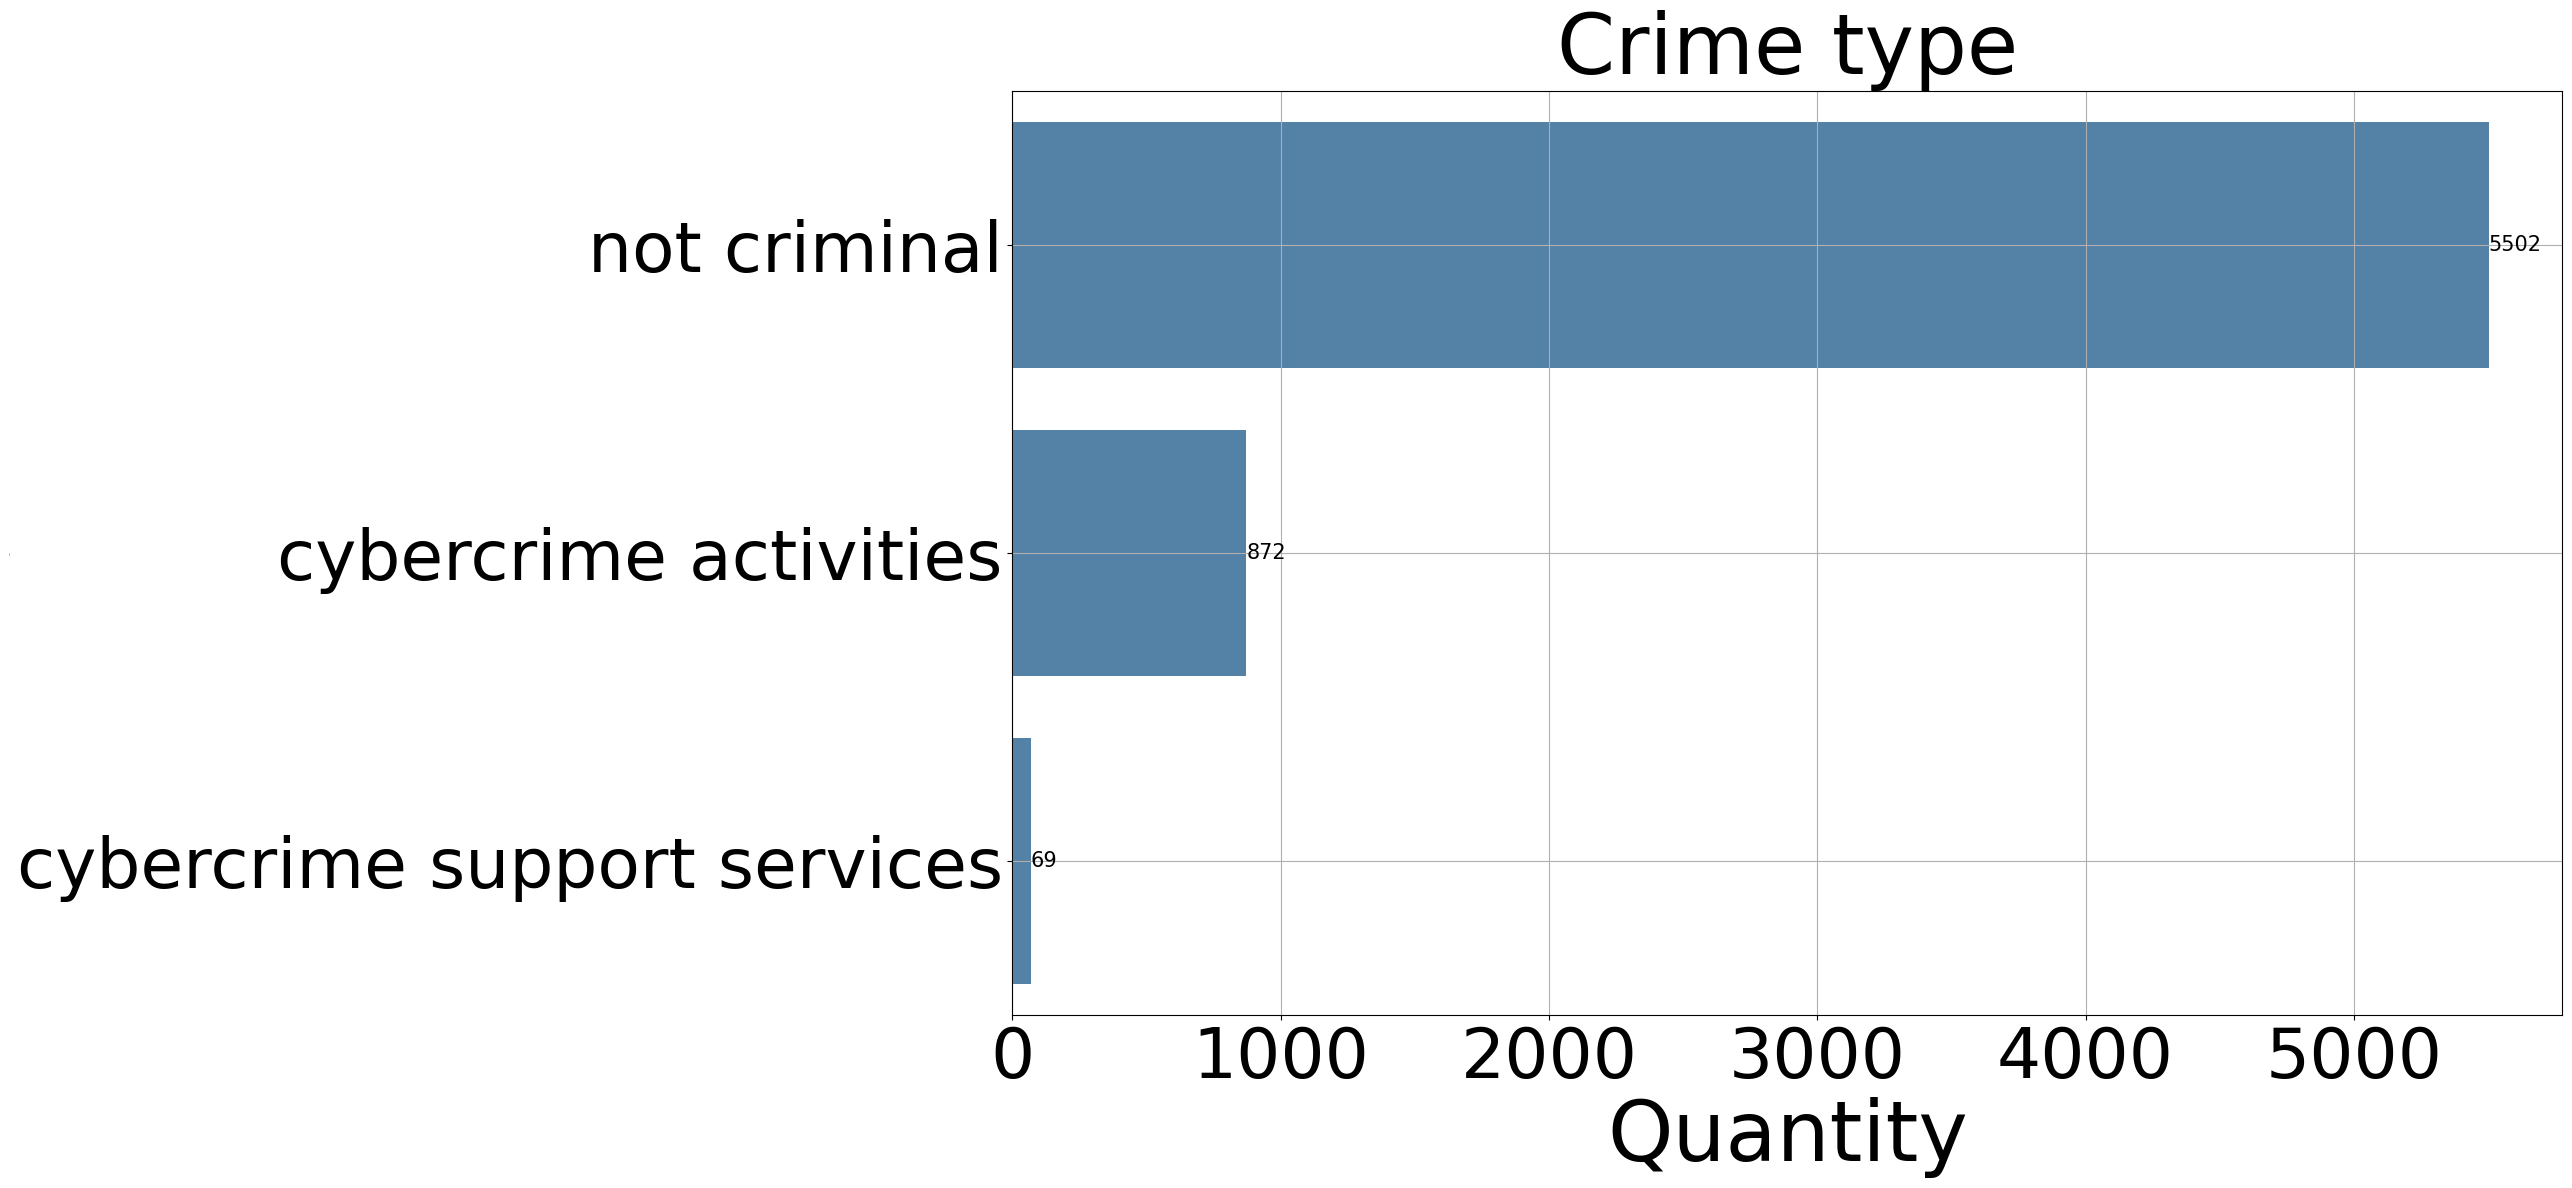

In [32]:
_, ax = plt.subplots(figsize=(20,12), nrows=1, ncols=1, sharex=False, sharey=False)

estado_df = pd.pivot_table(filter_df,
               index=["chatgpt_crimetype"],
                values=["thread_id"],
                aggfunc={
                    "thread_id":len
                }).reset_index()

sns_fig = sns.barplot(
            data=estado_df,
            x=estado_df.columns[1],
            y=estado_df.columns[0],
            orient="h",
            ax=ax,
            color="steelblue",
            order=estado_df.sort_values(estado_df.columns[1], ascending=False)[estado_df.columns[0]]
           )

sns_fig.set_title(f"Crime type", fontsize=60)
sns_fig.set_ylabel(f"Label", fontsize=0)
sns_fig.set_xlabel('Quantity', fontsize=60)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0, labelsize=50)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='y', labelsize=50)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f', fontsize=15,rotation=0)

# add a space on y for the annotations
#sns_fig.margins(x=0.1)
ax.grid(True)

### Confusion Matrix original labels vs ChatGPt labels

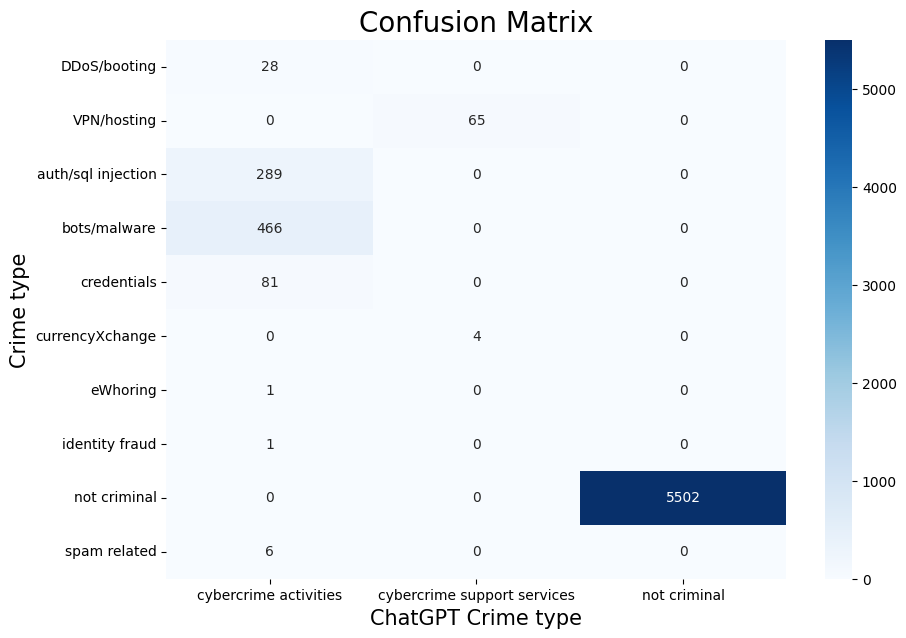

In [33]:
confusion_matrix = pd.crosstab(filter_df['crimetype'], filter_df['chatgpt_crimetype'], rownames=['crimetype'], colnames=['chatgpt_crimetype'])

plt.figure(figsize=(10, 7))
sns_heatmap = sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues', cbar=True)

# Customize the plot
sns_heatmap.set_title('Confusion Matrix', fontsize=20)
sns_heatmap.set_xlabel('ChatGPT Crime type', fontsize=15)
sns_heatmap.set_ylabel('Crime type', fontsize=15)

# Display the plot
plt.show()

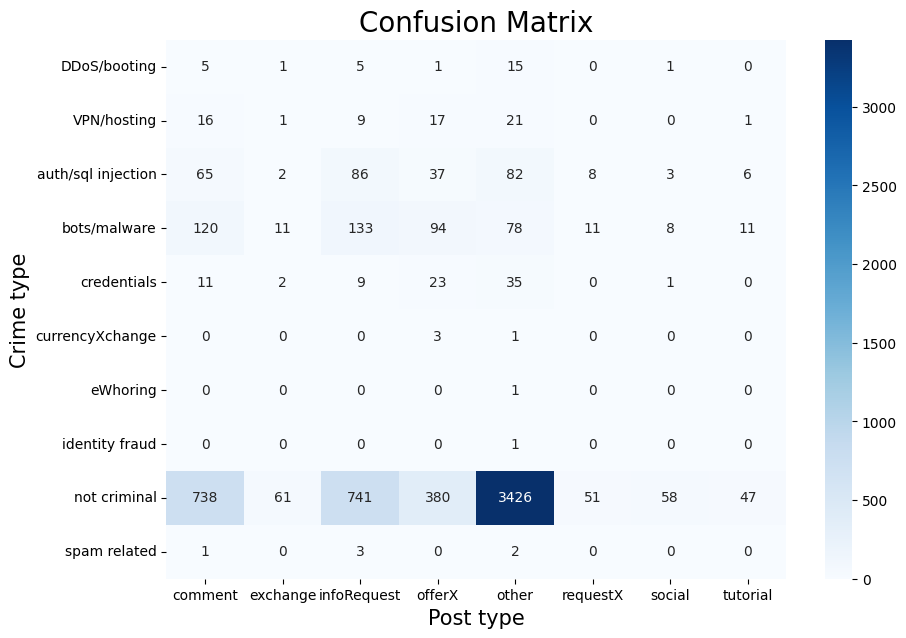

In [34]:
confusion_matrix = pd.crosstab(filter_df['crimetype'], filter_df['posttype'], rownames=['crimetype'], colnames=['posttype'])

plt.figure(figsize=(10, 7))
sns_heatmap = sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues', cbar=True)

# Customize the plot
sns_heatmap.set_title('Confusion Matrix', fontsize=20)
sns_heatmap.set_xlabel('Post type', fontsize=15)
sns_heatmap.set_ylabel('Crime type', fontsize=15)

# Display the plot
plt.show()

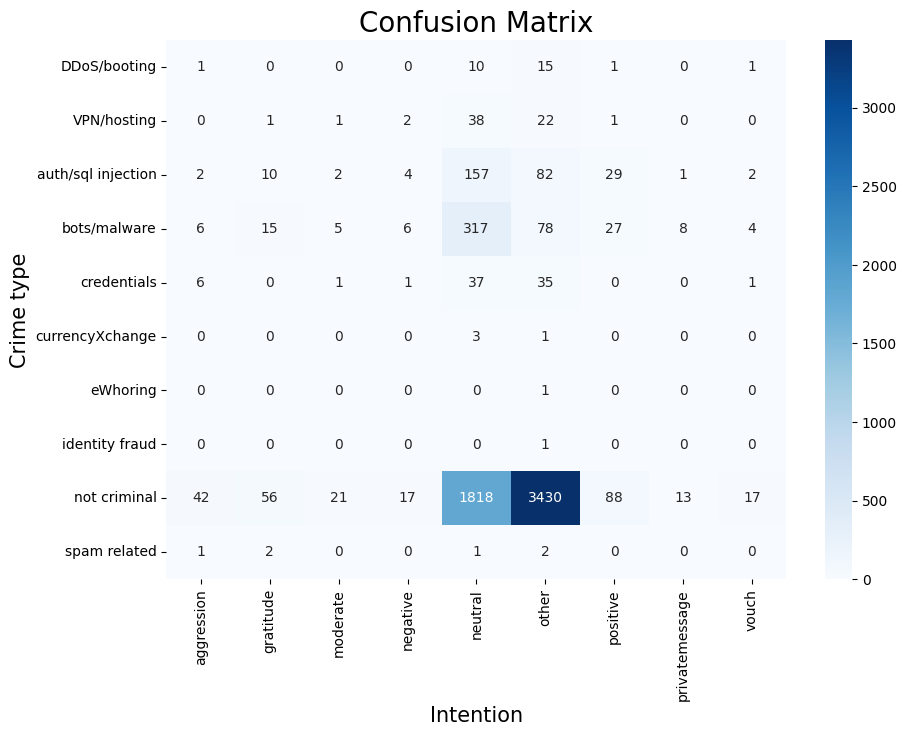

In [35]:
confusion_matrix = pd.crosstab(filter_df['crimetype'], filter_df['intention'], rownames=['crimetype'], colnames=['intention'])

plt.figure(figsize=(10, 7))
sns_heatmap = sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues', cbar=True)

# Customize the plot
sns_heatmap.set_title('Confusion Matrix', fontsize=20)
sns_heatmap.set_xlabel('Intention', fontsize=15)
sns_heatmap.set_ylabel('Crime type', fontsize=15)

# Display the plot
plt.show()

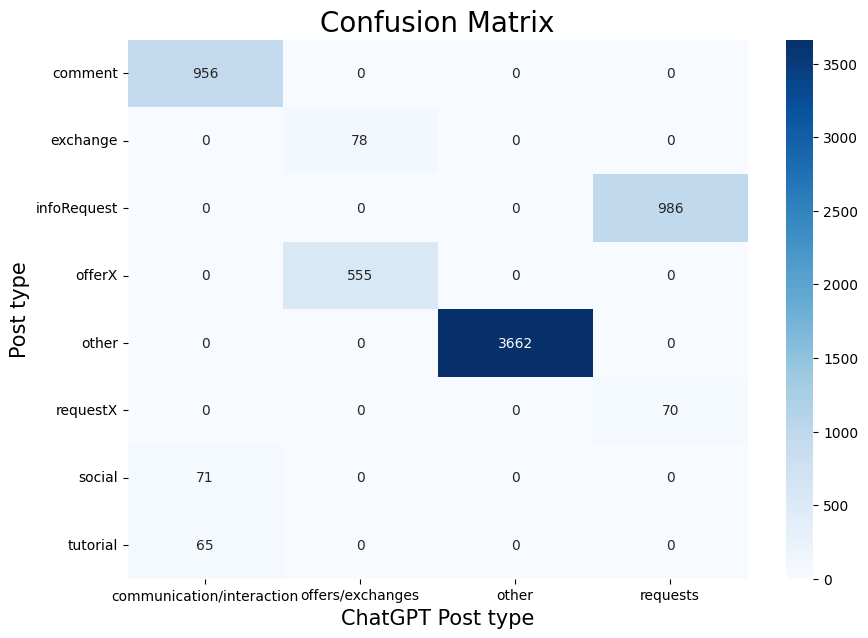

In [36]:
confusion_matrix = pd.crosstab(filter_df['posttype'], filter_df['chatgpt_posttype'], rownames=['posttype'], colnames=['chatgpt_posttype'])

plt.figure(figsize=(10, 7))
sns_heatmap = sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues', cbar=True)

# Customize the plot
sns_heatmap.set_title('Confusion Matrix', fontsize=20)
sns_heatmap.set_xlabel('ChatGPT Post type', fontsize=15)
sns_heatmap.set_ylabel('Post type', fontsize=15)

# Display the plot
plt.show()

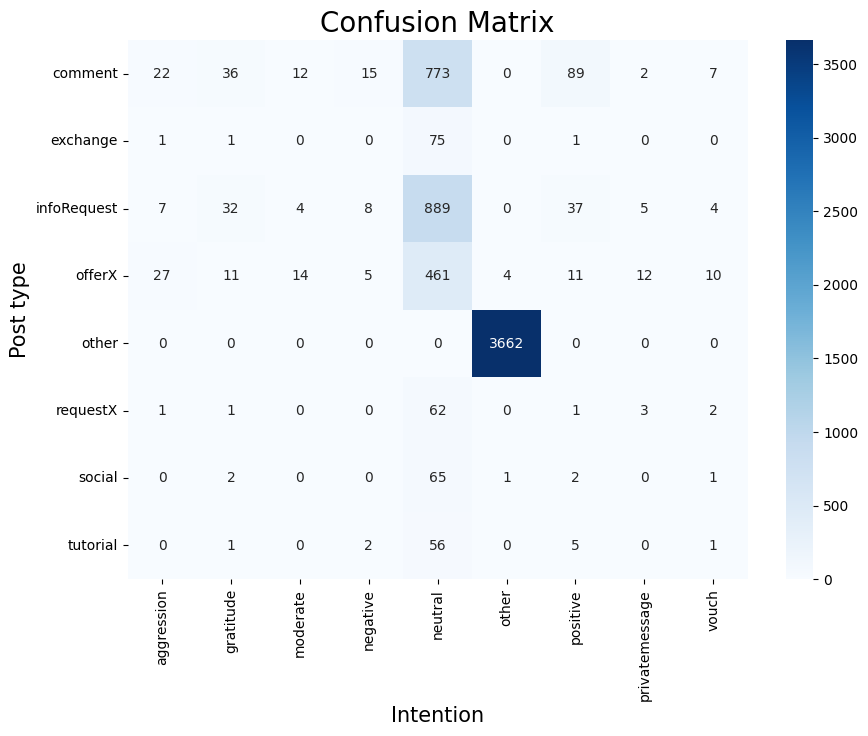

In [37]:
confusion_matrix = pd.crosstab(filter_df['posttype'], filter_df['intention'], rownames=['posttype'], colnames=['intention'])

plt.figure(figsize=(10, 7))
sns_heatmap = sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues', cbar=True)

# Customize the plot
sns_heatmap.set_title('Confusion Matrix', fontsize=20)
sns_heatmap.set_xlabel('Intention', fontsize=15)
sns_heatmap.set_ylabel('Post type', fontsize=15)

# Display the plot
plt.show()

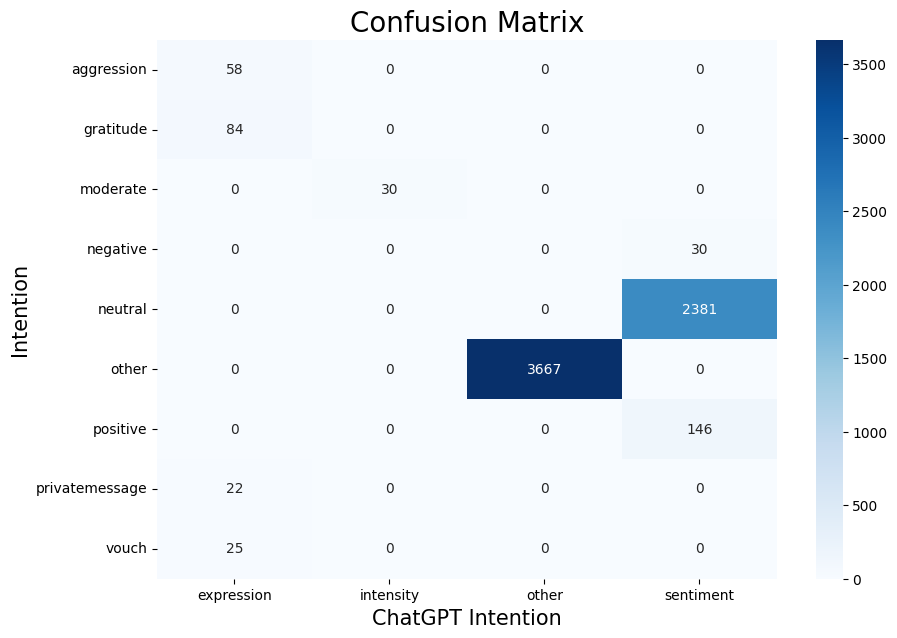

In [38]:
confusion_matrix = pd.crosstab(filter_df['intention'], filter_df['chatgpt_intention'], rownames=['posttype'], colnames=['chatgpt_intention'])

plt.figure(figsize=(10, 7))
sns_heatmap = sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues', cbar=True)

# Customize the plot
sns_heatmap.set_title('Confusion Matrix', fontsize=20)
sns_heatmap.set_xlabel('ChatGPT Intention', fontsize=15)
sns_heatmap.set_ylabel('Intention', fontsize=15)

# Display the plot
plt.show()

In [40]:
filter_df.to_csv(f"{THREADS_PROCESSED}Websites_LLM_Labels.csv", sep='\t', index=False)